In [2]:
# see all table names in the file 
import sqlite3
import pandas as pd

# Connect to your database
conn = sqlite3.connect(r"C:\Users\tyler\Downloads\enrollment_42426.db")

# See all tables
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

conn.close()


                name
0  enrollment_master
1    sqlite_sequence


In [3]:
# look at data 
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tyler\Downloads\enrollment_42426.db")

df = pd.read_sql_query("SELECT * FROM enrollment_master;", conn)
conn.close()

df.head()


,id,academic_period,t_number,student_name,last_name,first_name,middle_name,name_prefix,middle_initial,name_suffix,...,previous_term_hours_attempted,previous_term_academic_standing_end,beginning_academic_standing_for_term_of_interest,current_holds,graduation_application,last_term_registered,current_balance,previous_term_ests_code,previous_term_ests_desc,previous_term_ests_date
0,1,fall_2019,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,2,fall_2019,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,3,fall_2019,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,4,fall_2019,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,5,fall_2019,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [4]:
# clean data in file 
df = df.replace('None', pd.NA) # get rid of the word 'None'
# df.shape # (138266, 270)

df = df[df['t_number'].notna()] # if the t_number is 'NA' drop it 
df.shape # (133792, 270) -4474

# remove from data frame if t_number and academic_period duplicate keep last instance
df = df.drop_duplicates(subset=['t_number', 'academic_period'], keep='last')
df.shape # (12599, 270) -121193

# df.head()

(12599, 270)

In [5]:
print(df.columns.tolist())

['id', 'academic_period', 't_number', 'student_name', 'last_name', 'first_name', 'middle_name', 'name_prefix', 'middle_initial', 'name_suffix', 'preferred_first_name', 'relative_that_attended_atu', 'primary_advisor_name_lfmi', 'program_code', 'program_desc', 'primary_program_ind', 'student_level', 'student_level_desc', 'campus', 'college', 'department_desc', 'major_desc', 'first_concentration', 'second_concentration', 'first_minor', 'first_minor_desc', 'second_minor', 'second_minor_desc', 'student_type', 'student_class_code', 'student_classification', 'academic_standing_beg_code', 'academic_standing_beginning', 'academic_standing_end_code', 'academic_standing_end', 'deans_list_value', 'deceased_status', 'deceased_date', 'confidentiality_ind', 'birth_date', 'current_age', 'gender', 'ethnicity', 'ethnicity_code', 'residency', 'phone_number', 'phone_unlisted_ind', 'phone_type', 'cell_phone', 'preferred_email', 'campus_housing', 'current_gpa', 'current_gpa_hours', 'current_hours_attempted'

In [6]:
df['academic_period'].unique()

array(['fall_2019', 'fall_2020', 'fall_2021', 'fall_2022', 'fall_2023',
       'fall_2024', 'fall_2025', 'spring_2020', 'spring_2022',
       'spring_2023', 'spring_2024', 'spring_2025'], dtype=object)

In [12]:
df['student_classification'].unique()

array([None, 'Graduate Level', 'Freshman', 'Junior', 'Sophomore',
       'Senior', 'STUDENT_CLASSIFICATION', 'Business'], dtype=object)

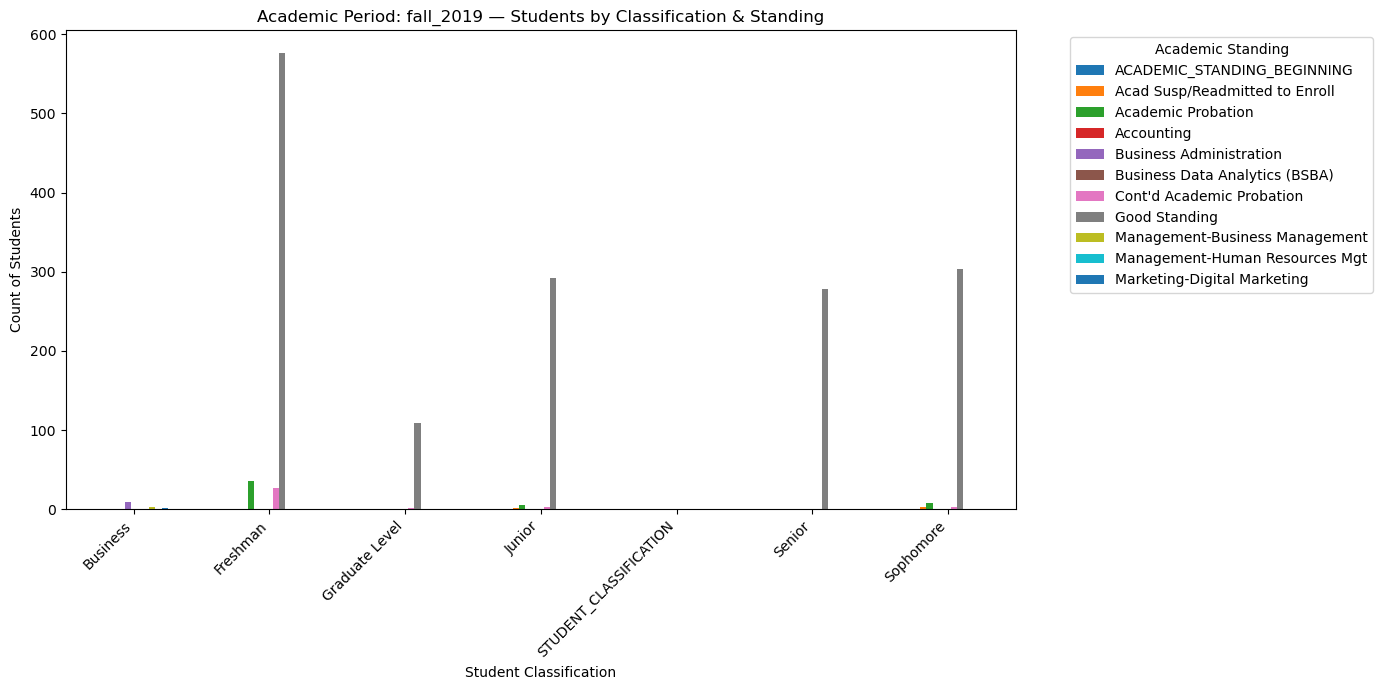

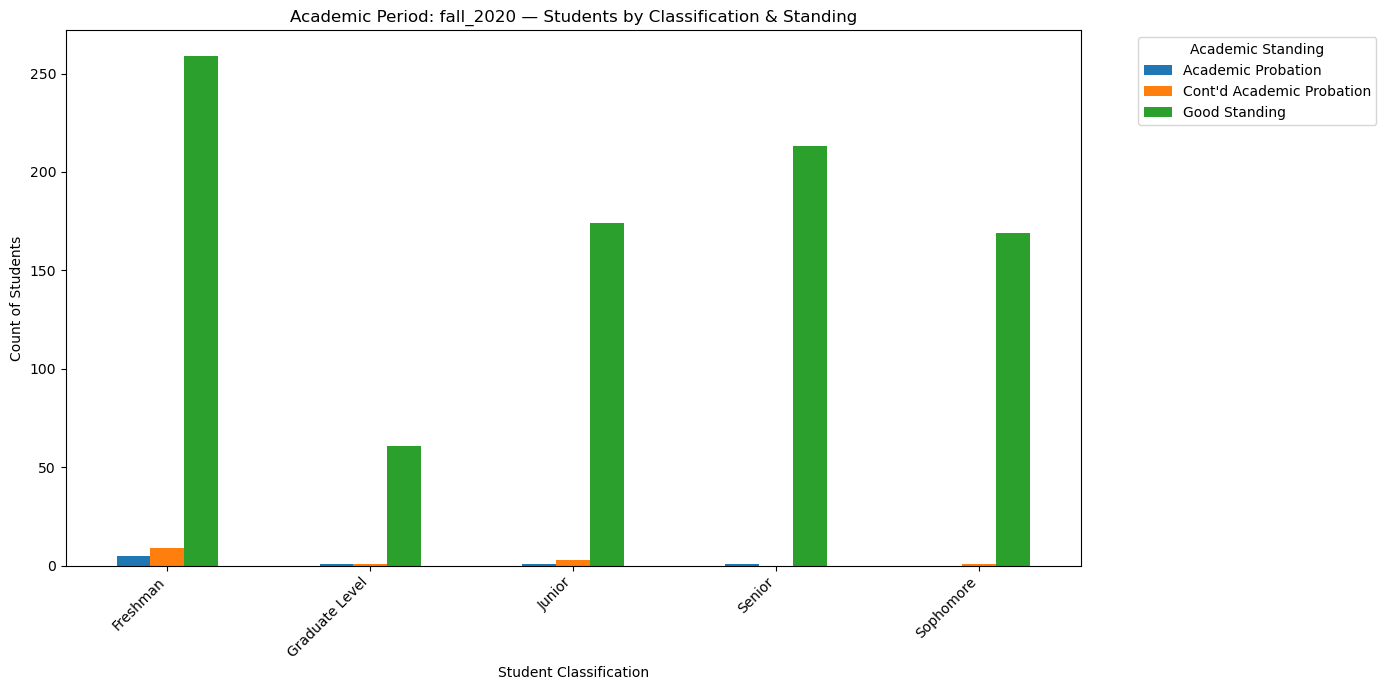

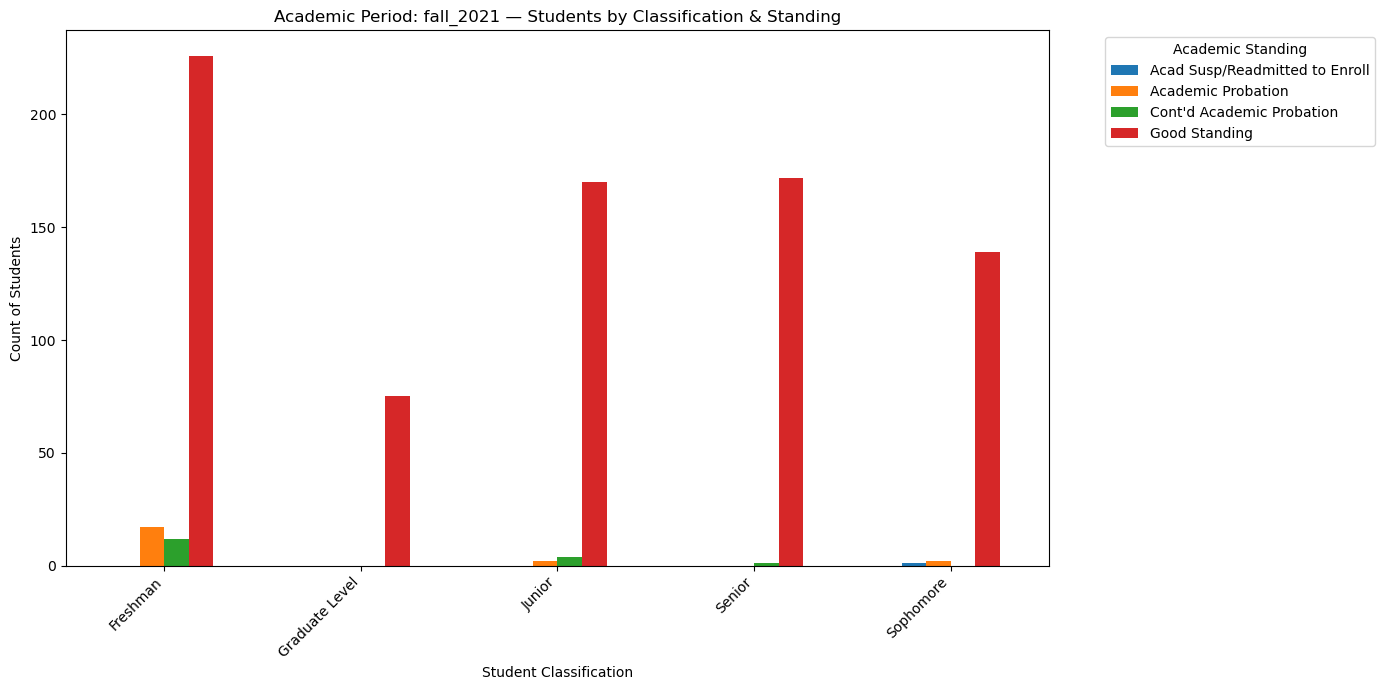

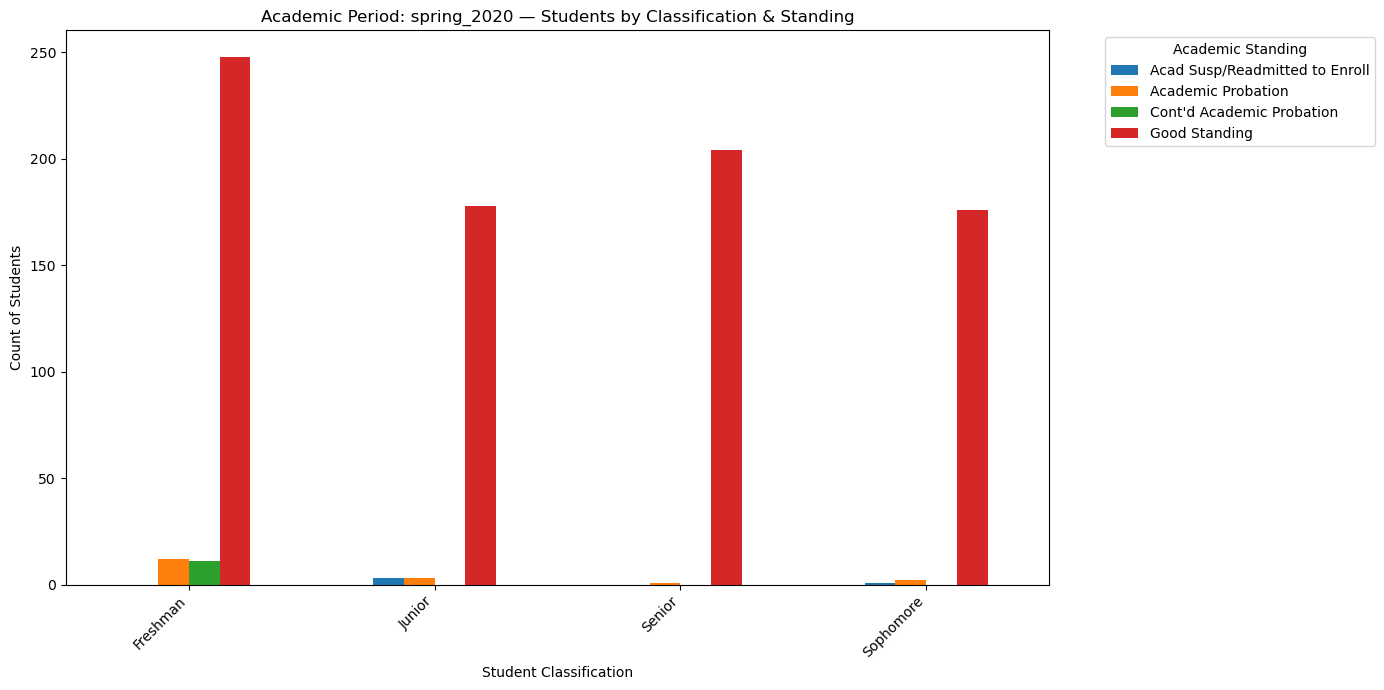

In [18]:
# how many students per level by period
year_class = df.groupby(['academic_period', 'student_classification', 'academic_standing_beginning'])['t_number'].count().reset_index()
year_class

import matplotlib.pyplot as plt

year_class = df.groupby(['academic_period', 'student_classification', 'academic_standing_beginning'])['t_number'].count().reset_index()
year_class.columns = ['academic_period', 'student_classification', 'academic_standing_beginning', 'count']

for period, group in year_class.groupby('academic_period'):
    pivot = group.pivot_table(index='student_classification', columns='academic_standing_beginning', values='count', fill_value=0)
    
    if pivot.empty:
        continue
    
    fig, ax = plt.subplots(figsize=(14, 7))
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'Academic Period: {period} — Students by Classification & Standing')
    ax.set_xlabel('Student Classification')
    ax.set_ylabel('Count of Students')
    ax.legend(title='Academic Standing', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

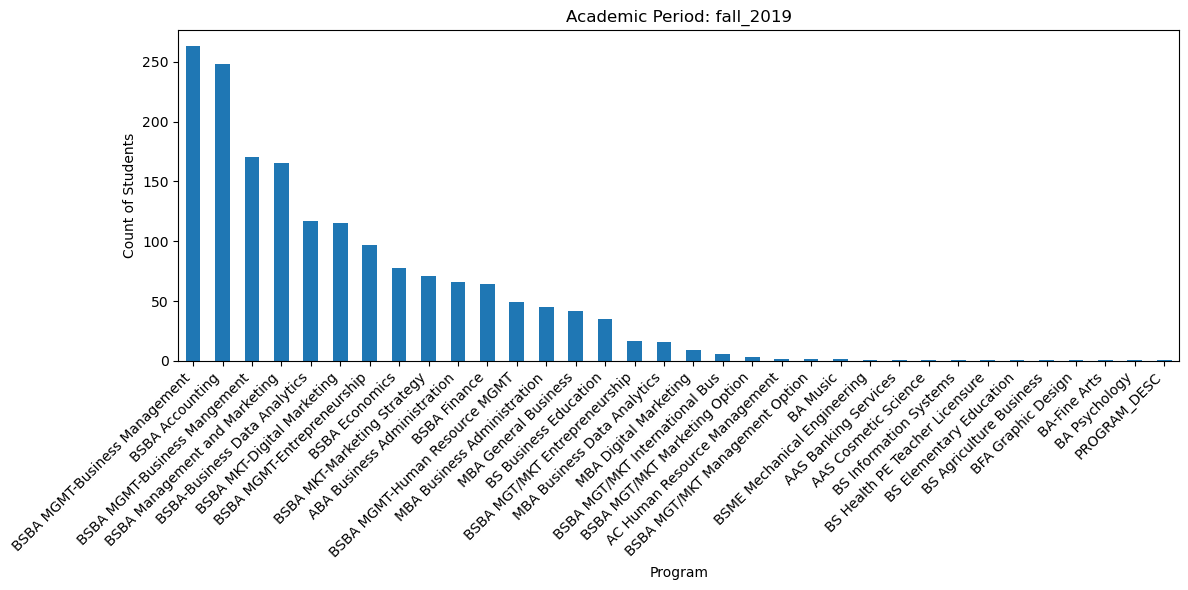

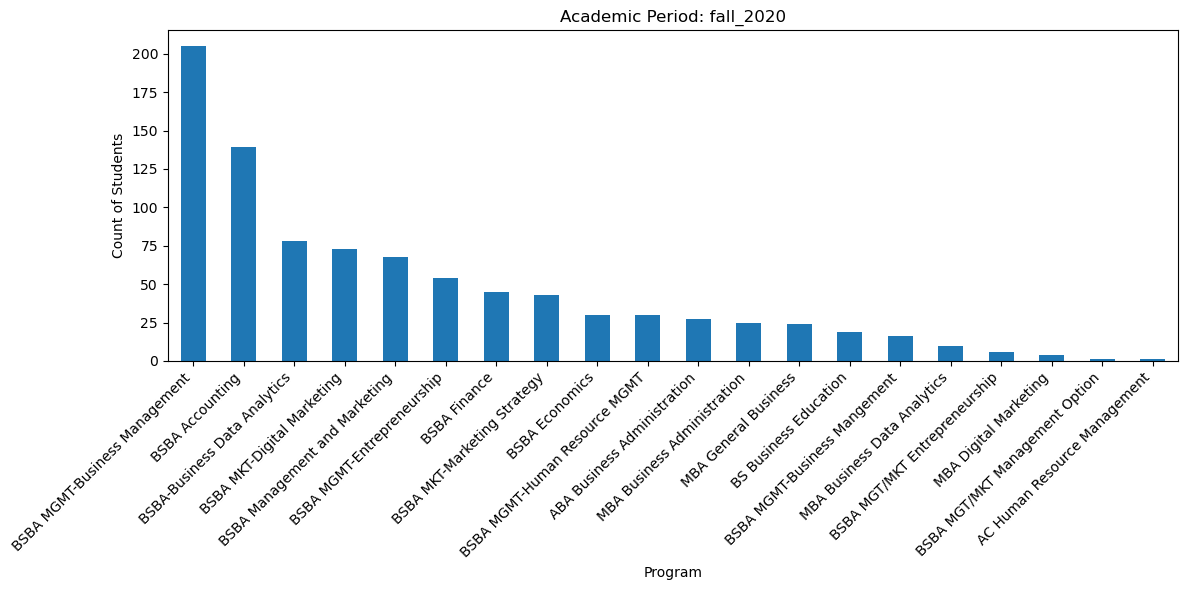

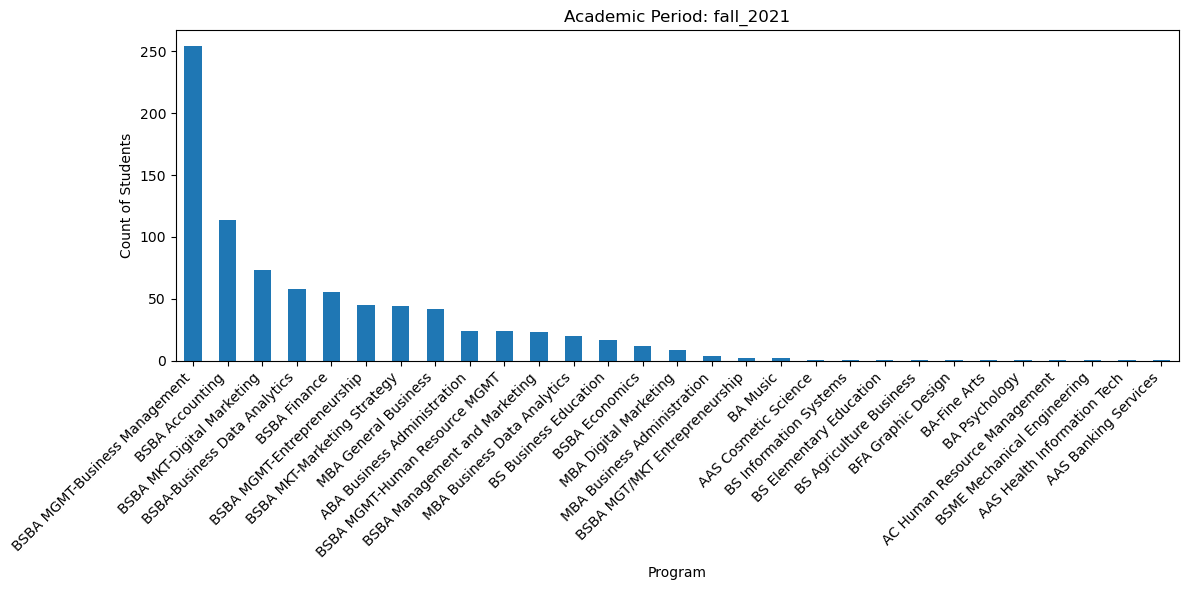

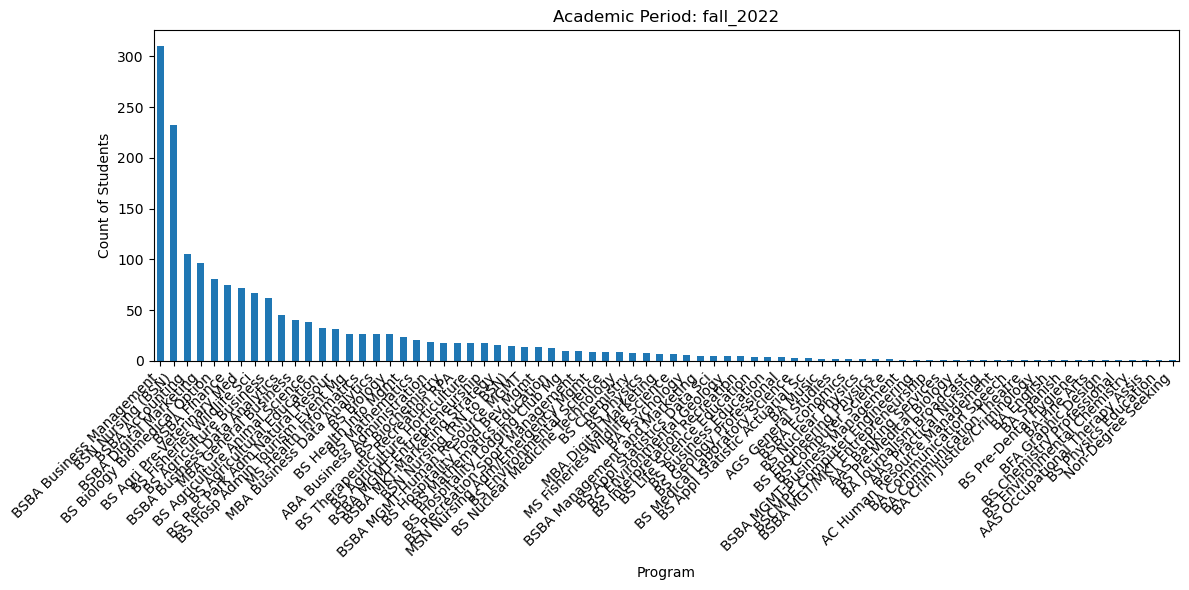

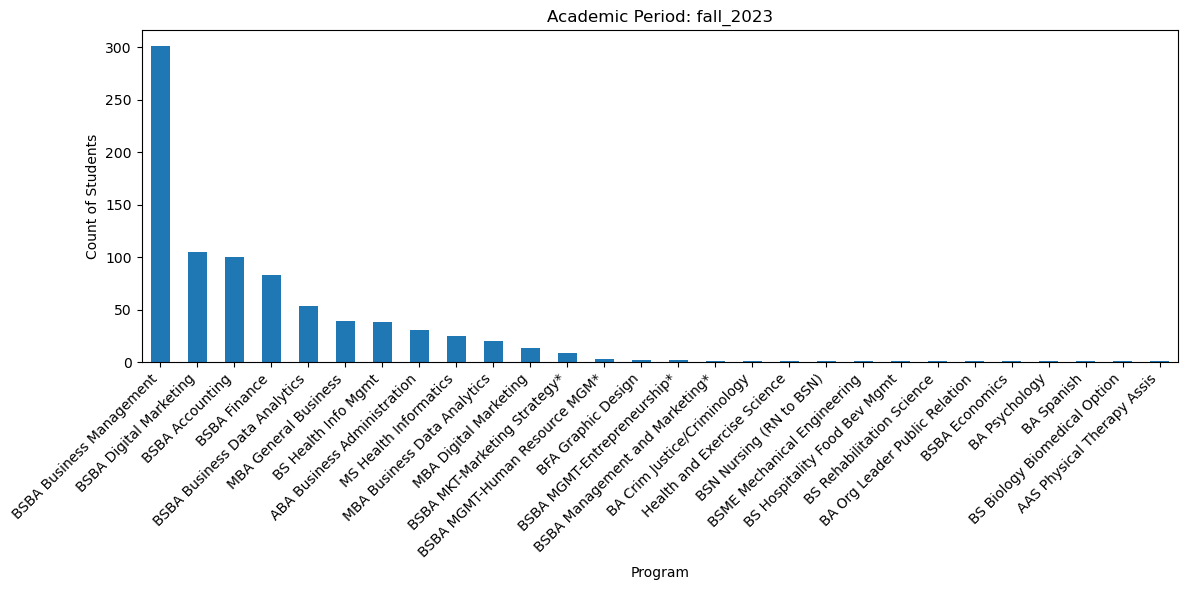

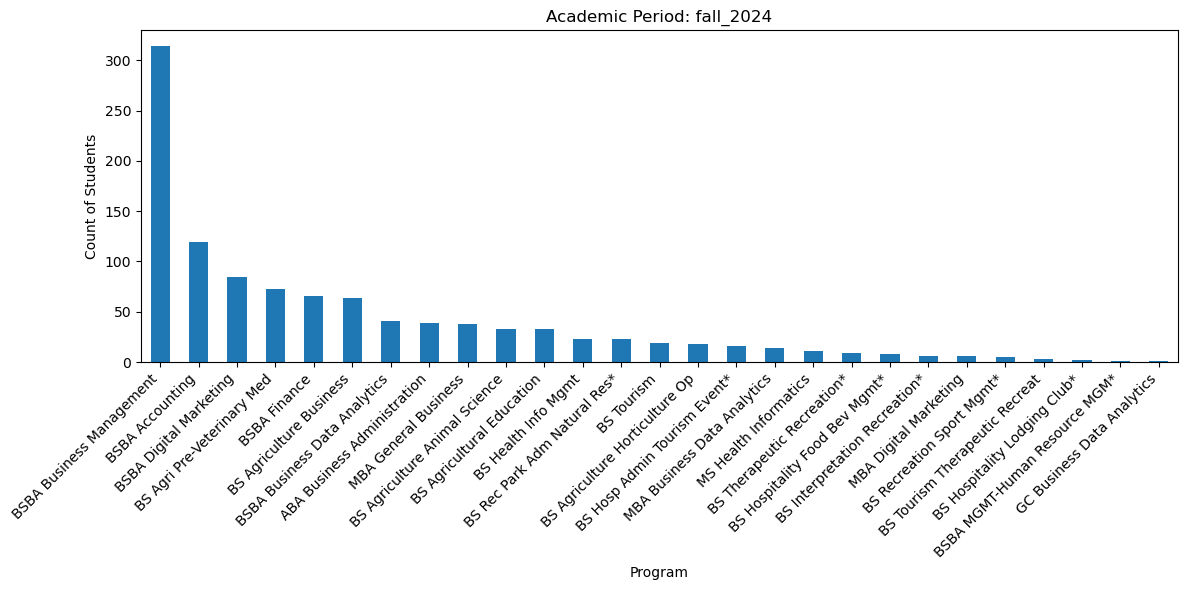

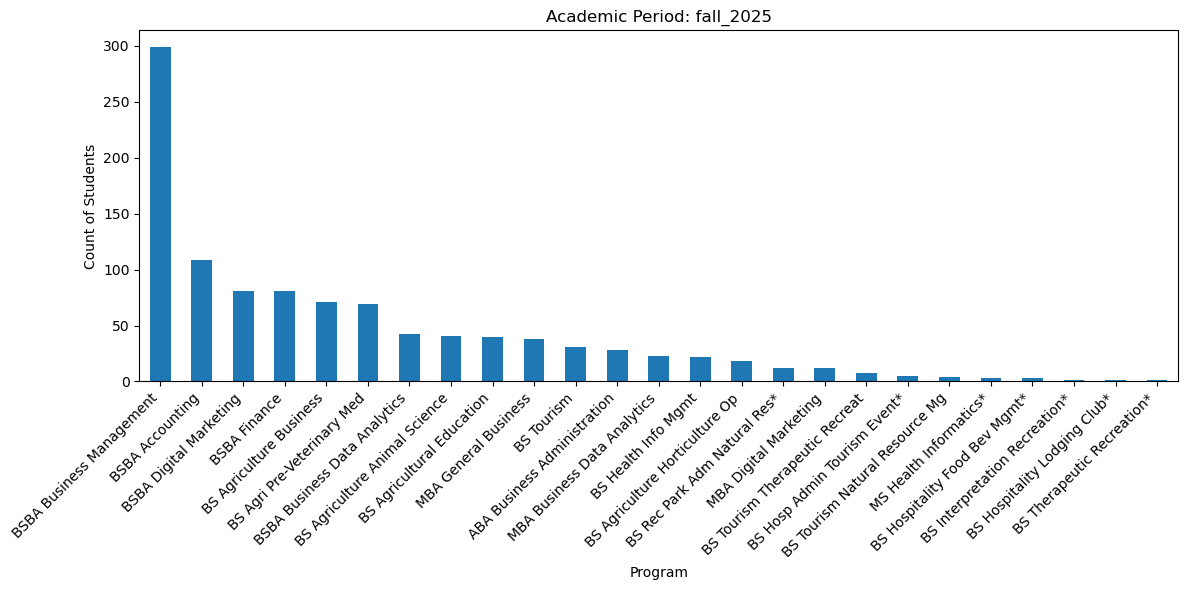

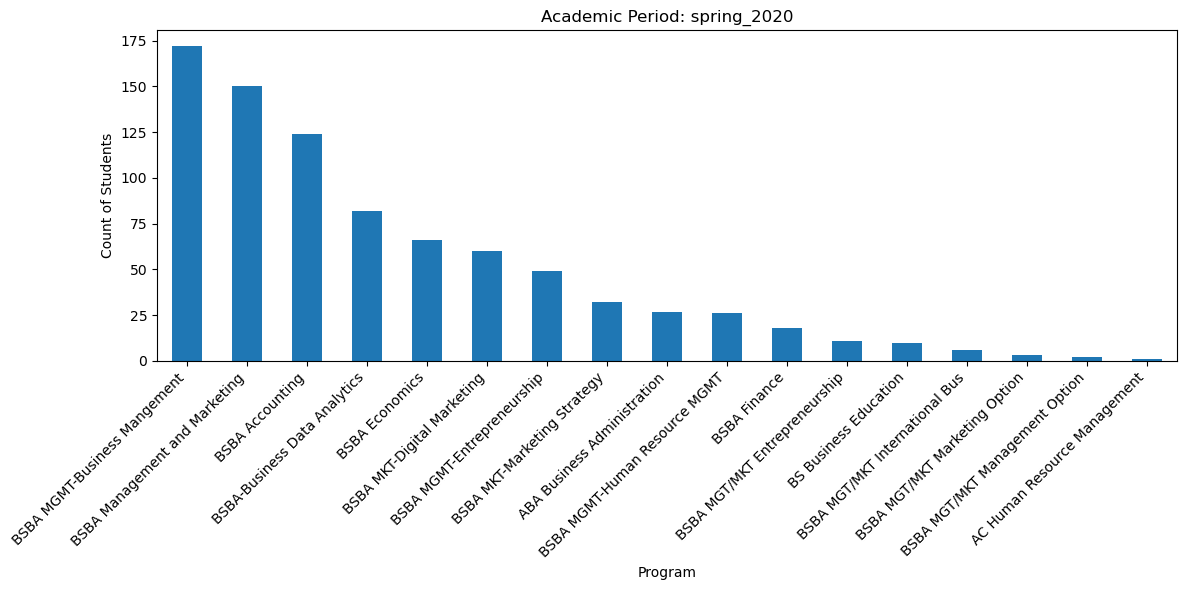

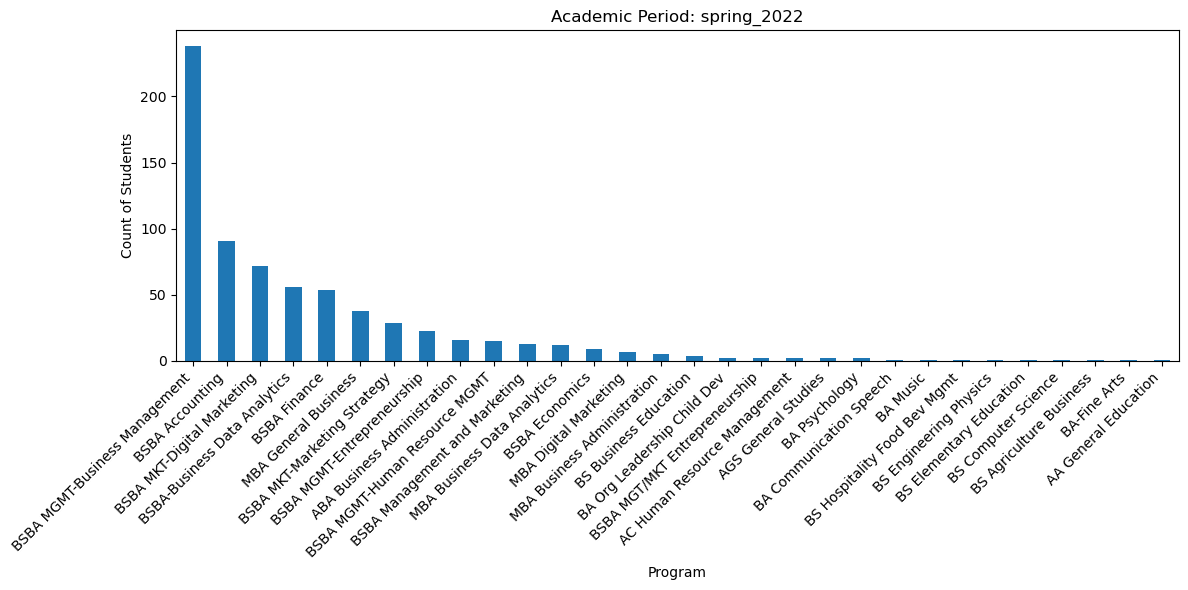

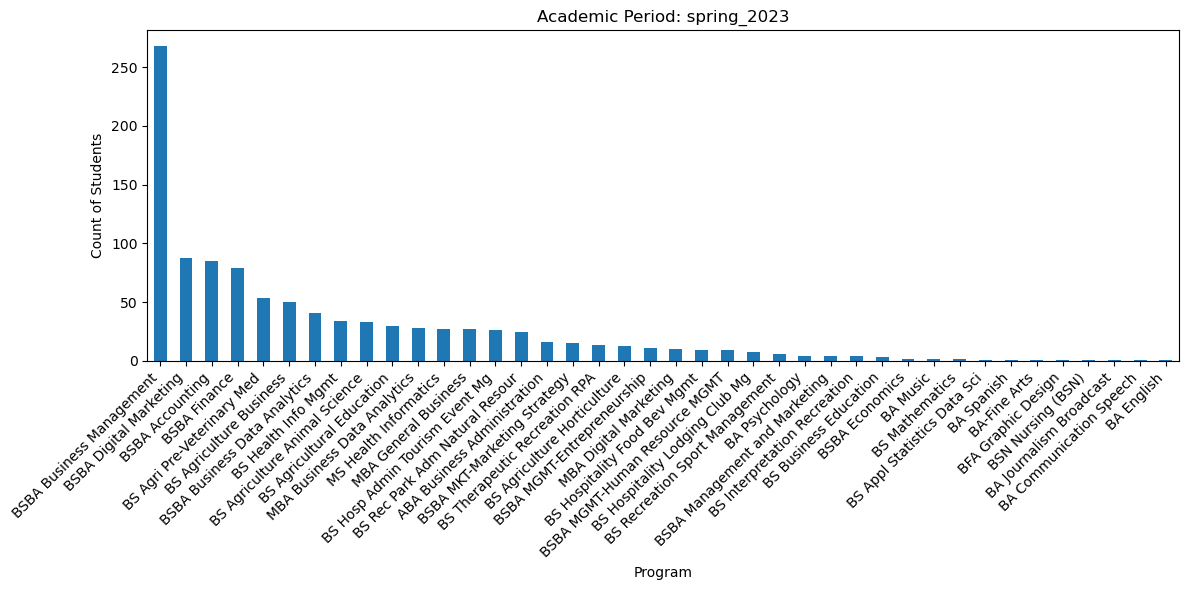

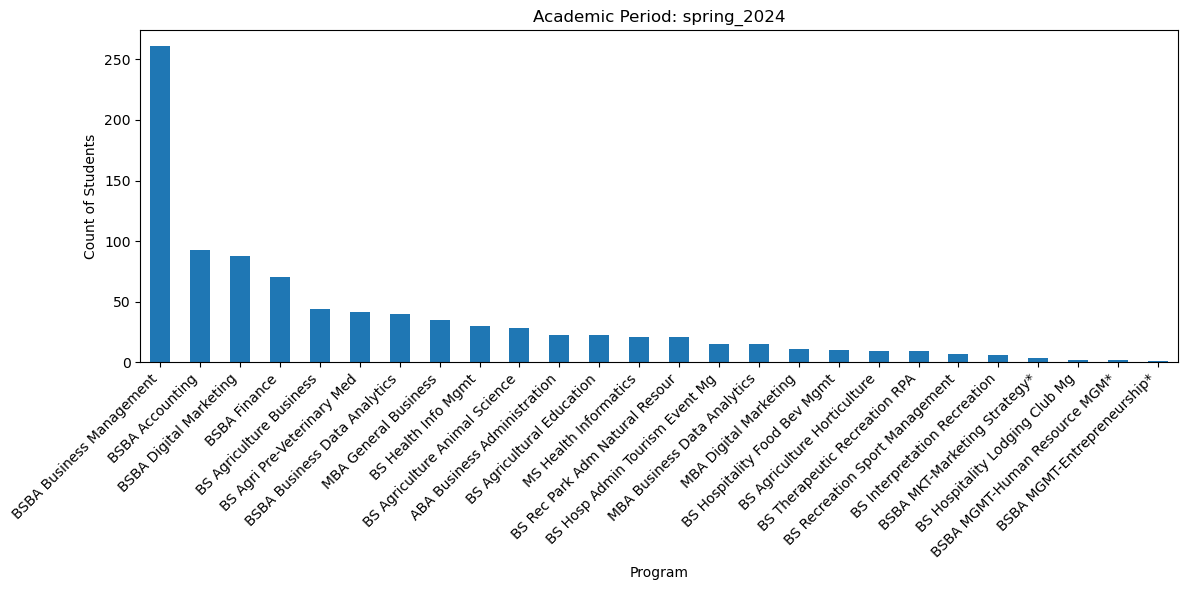

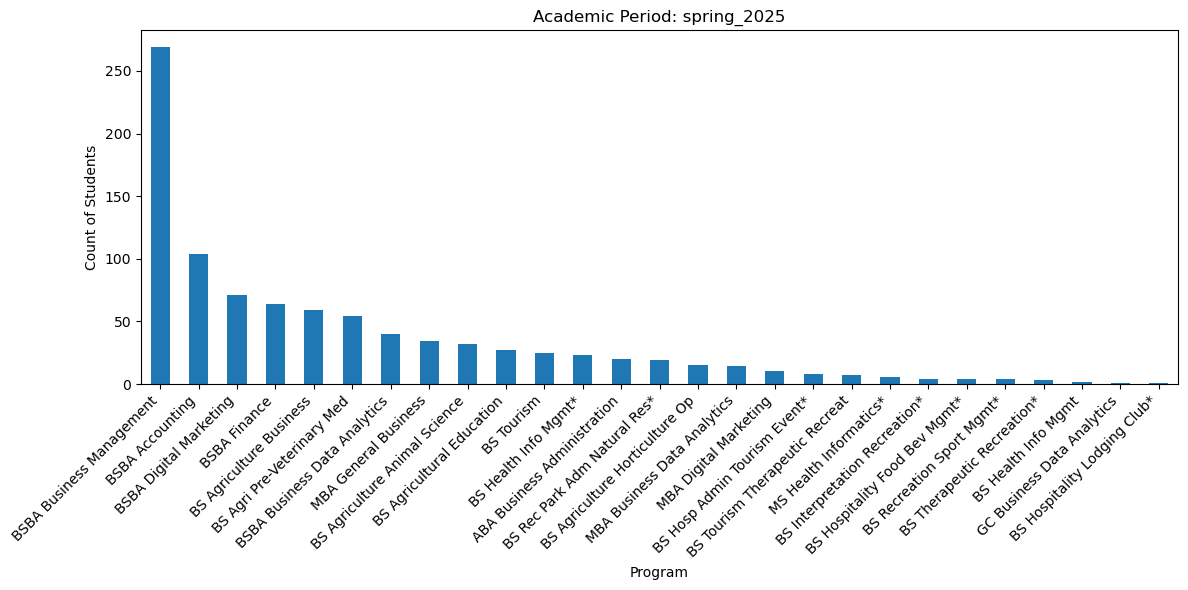

In [19]:
# how many are in each program_desc based by academic_period count of t_number
import matplotlib.pyplot as plt

for period, group in df.groupby('academic_period'):
    counts = group.groupby('program_desc')['t_number'].count().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Academic Period: {period}')
    ax.set_xlabel('Program')
    ax.set_ylabel('Count of Students')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [27]:
classification_map = {
    'Freshman': 1,
    'Sophomore': 2,
    'Junior': 3,
    'Senior': 4,
    'None': 0,
    None: 0
}

df['classification_num'] = df['classification'].map(classification_map)

# filter out None/0 classifications before plotting
df_plot = df[df['classification_num'] > 0]

classification_order = ['Freshman', 'Sophomore', 'Junior', 'Senior']

for period, group in df_plot.groupby('academic_period'):
    pivot = group.groupby(['program_desc', 'classification'])['t_number'].count().unstack(fill_value=0)
    pivot = pivot.reindex(columns=classification_order, fill_value=0)
    
    # skip if pivot is empty
    if pivot.empty or pivot.values.sum() == 0:
        print(f"Skipping period {period} — no data")
        continue
    
    fig, ax = plt.subplots(figsize=(14, 7))
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'Academic Period: {period}')
    ax.set_xlabel('Program')
    ax.set_ylabel('Count of Students')
    ax.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Skipping period spring_2024 — no data
